# SkinLens AI

## AI Powered Skin Cancer Detection

Dataset:
ISIC 2024 Challenge


---

## Objectives

- Build production-ready AI pipeline
- Train EfficientNet Baseline
- Hybrid Image + Metadata Model
- Explainability
- Streamlit Deployment
- Docker Deployment

---

In [1]:
import torch

print("PyTorch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch Version: 2.10.0+cpu
CUDA Available: False


## Install Required Libraries

In [2]:
!pip install numpy pandas matplotlib seaborn opencv-python
!pip install torch torchvision timm
!pip install albumentations
!pip install scikit-learn
!pip install tqdm
!pip install tensorboard
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 56.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44285 sha256=69441eca862531f1d010ea8d596882d8aa532d79c8eab05525e0992b137d637c
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


## Import Libraries

In [3]:
import os
import random
import shutil
import warnings
from pathlib import Path

import cv2
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

warnings.filterwarnings("ignore")

In [4]:
import torch
import torchvision
import timm

from torch import nn
from torch.utils.data import Dataset, DataLoader

print("Torch Version :", torch.__version__)
print("TorchVision :", torchvision.__version__)
print("TIMM :", timm.__version__)

Torch Version : 2.10.0+cpu
TorchVision : 0.25.0+cpu
TIMM : 1.0.26


## Random Seed

In [5]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("Seed Fixed :", SEED)

Seed Fixed : 42


## GPU Information

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device :", device)

if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))
    print("GPU Count :", torch.cuda.device_count())
else:
    print("Running on CPU")

Device : cpu
Running on CPU


## Create Project Structure

In [7]:
PROJECT_DIR = Path.cwd().parent

folders = [

    "data/raw",
    "data/subsets",
    "data/processed",

    "outputs",

    "outputs/models",
    "outputs/logs",
    "outputs/plots",
    "outputs/checkpoints",

    "configs",

    "src",

    "notebooks",

    "docs"

]

for folder in folders:
    Path(PROJECT_DIR / folder).mkdir(parents=True, exist_ok=True)

print("Folders Created Successfully")

Folders Created Successfully


In [8]:
for root, dirs, files in os.walk(PROJECT_DIR):

    level = root.replace(str(PROJECT_DIR), "").count(os.sep)

    indent = " " * 4 * level

    print(f"{indent}{os.path.basename(root)}/")

kaggle/
    outputs/
        plots/
        logs/
        models/
        checkpoints/
    src/
    data/
        subsets/
        processed/
        raw/
    lib/
    kaggle/
    input/
        competitions/
            isic-2024-challenge/
                train-image/
                    image/
    configs/
    huggingface/
    docs/
    nbdev/
    working/
    notebooks/


## Dataset Path

In [9]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)

/kaggle/input
/kaggle/input/competitions
/kaggle/input/competitions/isic-2024-challenge
/kaggle/input/competitions/isic-2024-challenge/train-image
/kaggle/input/competitions/isic-2024-challenge/train-image/image


In [10]:
from pathlib import Path

DATA_DIR = Path("/kaggle/input/competitions/isic-2024-challenge")

print(DATA_DIR.exists())

True


In [11]:
for file in DATA_DIR.iterdir():
    print(file)

/kaggle/input/competitions/isic-2024-challenge/sample_submission.csv
/kaggle/input/competitions/isic-2024-challenge/train-metadata.csv
/kaggle/input/competitions/isic-2024-challenge/test-metadata.csv
/kaggle/input/competitions/isic-2024-challenge/test-image.hdf5
/kaggle/input/competitions/isic-2024-challenge/train-image
/kaggle/input/competitions/isic-2024-challenge/train-image.hdf5


In [12]:
from pathlib import Path

# ===========================
# Dataset Paths
# ===========================

DATA_DIR = Path("/kaggle/input/competitions/isic-2024-challenge")

TRAIN_IMAGES = DATA_DIR / "train-image" / "image"

TRAIN_METADATA = DATA_DIR / "train-metadata.csv"

TEST_HDF5 = DATA_DIR / "test-image.hdf5"

TEST_METADATA = DATA_DIR / "test-metadata.csv"

print("Train Images :", TRAIN_IMAGES)
print("Metadata     :", TRAIN_METADATA)

Train Images : /kaggle/input/competitions/isic-2024-challenge/train-image/image
Metadata     : /kaggle/input/competitions/isic-2024-challenge/train-metadata.csv


In [13]:
print("Train Images Exists :", TRAIN_IMAGES.exists())
print("Metadata Exists     :", TRAIN_METADATA.exists())

Train Images Exists : True
Metadata Exists     : True


In [14]:
image_files = list(TRAIN_IMAGES.glob("*.jpg"))

print("Total Images :", len(image_files))

Total Images : 401059


ISIC_5116593.jpg


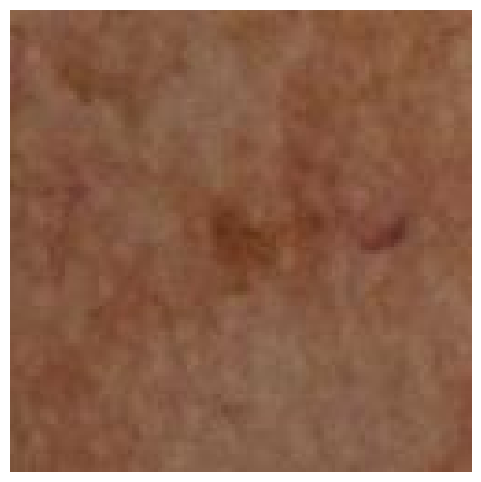

In [15]:
from PIL import Image
import matplotlib.pyplot as plt
import random

sample = random.choice(image_files)

print(sample.name)

img = Image.open(sample)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis("off")
plt.show()

In [16]:
import pandas as pd

df = pd.read_csv(TRAIN_METADATA)

print(df.shape)

df.head()

(401059, 55)


,isic_id,target,patient_id,age_approx,sex,anatom_site_general,clin_size_long_diam_mm,image_type,tbp_tile_type,tbp_lv_A,...,lesion_id,iddx_full,iddx_1,iddx_2,iddx_3,iddx_4,iddx_5,mel_mitotic_index,mel_thick_mm,tbp_lv_dnn_lesion_confidence
0,ISIC_0015670,0,IP_1235828,60.0,male,lower extremity,3.04,TBP tile: close-up,3D: white,20.244422,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,97.517282
1,ISIC_0015845,0,IP_8170065,60.0,male,head/neck,1.10,TBP tile: close-up,3D: white,31.712570,...,IL_6727506,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,3.141455
2,ISIC_0015864,0,IP_6724798,60.0,male,posterior torso,3.40,TBP tile: close-up,3D: XP,22.575830,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,99.804040
3,ISIC_0015902,0,IP_4111386,65.0,male,anterior torso,3.22,TBP tile: close-up,3D: XP,14.242329,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,99.989998
4,ISIC_0024200,0,IP_8313778,55.0,male,anterior torso,2.73,TBP tile: close-up,3D: white,24.725520,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,70.442510


In [17]:
missing = 0

for image_id in df["isic_id"][:100]:
    path = TRAIN_IMAGES / f"{image_id}.jpg"

    if not path.exists():
        missing += 1

print("Missing Images :", missing)

Missing Images : 0
